# 04 · GSE65391 · RNA_array · WGCNA soft threshold

Reads `expression.rds`. Writes `data/run_artifacts/GSE65391/wgcna_input.rds`.

WGCNA (Langfelder P, Horvath S. *BMC Bioinformatics* 2008;9:559) builds a gene network in which the
strength of a connection is the gene–gene correlation raised to a power β. β is chosen so the
network is approximately scale-free.

**Samples:** first visit of each child with SLE, one sample per child. 157 of the 158 children: child
SLE-222 has a single sample with no visit number in GEO (notebook 01) (WGCNA assumes independent
samples). **Genes:** the expressed genes from notebook 02. **Network:** signed.

**Rule for β** (WGCNA FAQ): the lowest power whose scale-free fit R² reaches 0.80. If no power
reaches it, the FAQ's fallback for a signed network with more than 40 samples is 12.

WGCNA has no conda build for Apple Silicon, so it is installed from CRAN here if missing.

In [1]:
if (!requireNamespace("WGCNA", quietly = TRUE)) install.packages("WGCNA", repos = "https://cloud.r-project.org")
suppressMessages(library(WGCNA))
packageVersion("WGCNA")

[1] ‘1.74’

In [2]:
source("../src/paths.R")
x  <- readRDS(art("GSE65391", "expression.rds"))
m  <- x$meta
fv <- rownames(m)[m$disease == "SLE" & m$first_visit]
datExpr <- t(x$E[x$expressed, fv])            # samples x genes, as WGCNA expects
dim(datExpr)

[1]  157 8825

**Check.** `goodSamplesGenes` flags genes or samples with too many missing values or zero variance.

In [3]:
gsg <- goodSamplesGenes(datExpr, verbose = 0)
c(all_ok = gsg$allOK, genes_flagged = sum(!gsg$goodGenes), samples_flagged = sum(!gsg$goodSamples))

all_ok   genes_flagged samples_flagged 
              1               0               0

**Result.** 157 samples × 8,825 genes; no gene or sample flagged.

**Outlier samples.** Hierarchical clustering of samples (average linkage, Euclidean distance).
A sample far from all others would show as a long isolated branch.

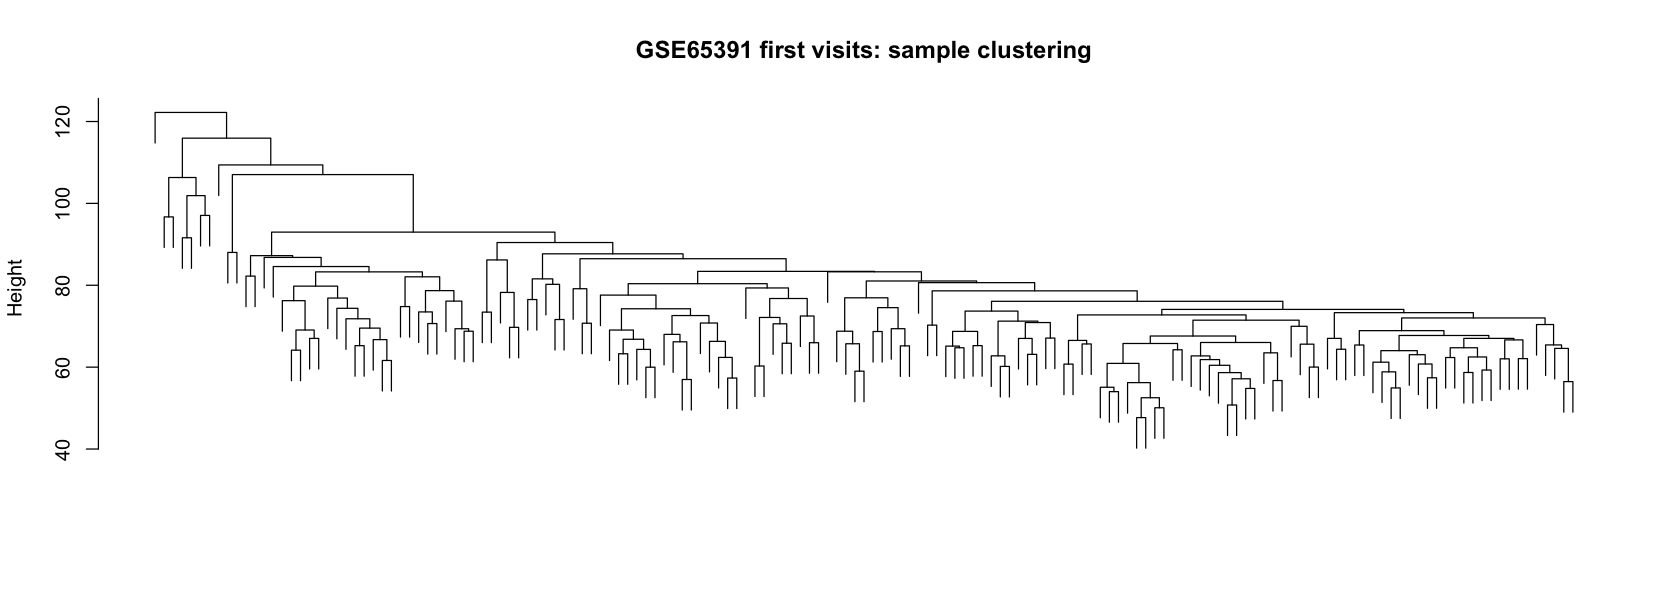

In [4]:
options(repr.plot.width = 14, repr.plot.height = 5)
plot(hclust(dist(datExpr), method = "average"), labels = FALSE, main = "GSE65391 first visits: sample clustering", xlab = "", sub = "")

In [5]:
powers <- c(1:10, seq(12, 30, 2))
invisible(capture.output(sft <- pickSoftThreshold(datExpr, powerVector = powers, networkType = "signed", verbose = 0)))
fit <- data.frame(power = sft$fitIndices$Power,
                  scale_free_R2 = round(-sign(sft$fitIndices$slope) * sft$fitIndices$SFT.R.sq, 3),
                  mean_connectivity = round(sft$fitIndices$mean.k., 1))
fit

Warning message:
“executing %dopar% sequentially: no parallel backend registered”


power,scale_free_R2,mean_connectivity
<dbl>,<dbl>,<dbl>
1,-0.584,4709.4
2,-0.155,2640.2
3,0.001,1545.8
4,0.115,940.4
5,0.317,591.7
6,0.492,383.4
7,0.586,255.1
8,0.637,173.7
9,0.685,120.7


In [6]:
reached <- fit$power[fit$scale_free_R2 >= 0.80]
POWER <- if (length(reached)) min(reached) else 12
c(power = POWER, rule = if (length(reached)) "lowest power with R2 >= 0.80" else "FAQ fallback, signed, > 40 samples")

power                           rule 
                          "20" "lowest power with R2 >= 0.80"

**Result.** β = 20: the lowest power with scale-free R² ≥ 0.80 (R² = 0.812, mean connectivity 5.3).

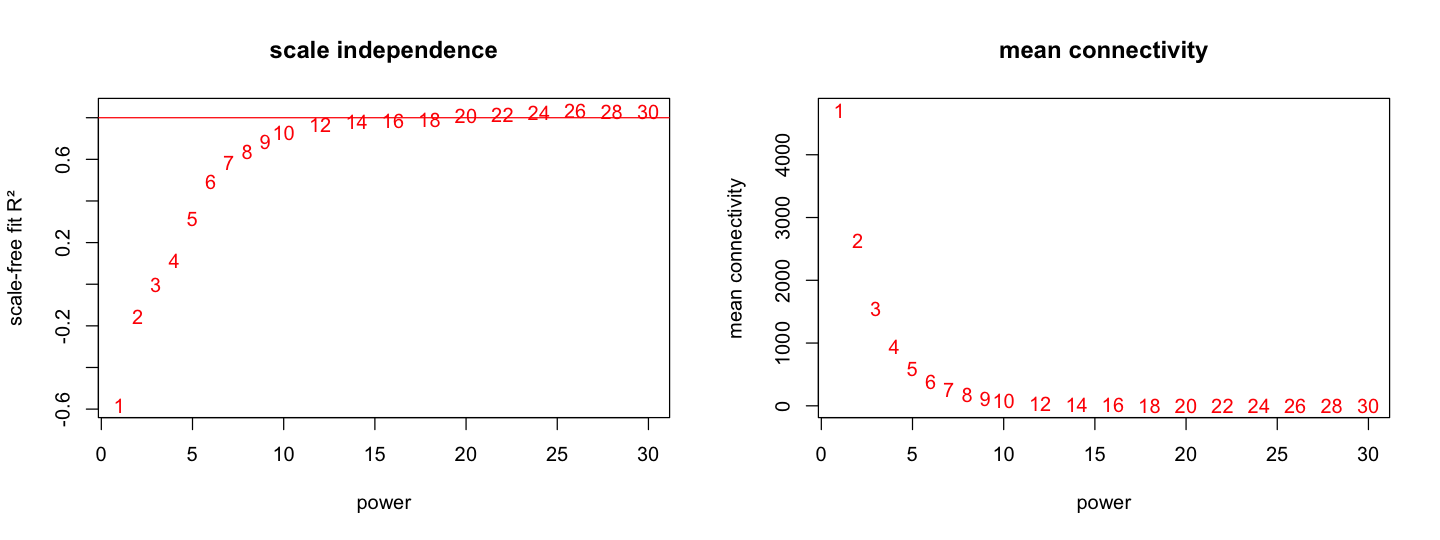

In [7]:
options(repr.plot.width = 12, repr.plot.height = 4.5)
par(mfrow = c(1, 2))
plot(fit$power, fit$scale_free_R2, type = "n", xlab = "power", ylab = "scale-free fit R²", main = "scale independence")
text(fit$power, fit$scale_free_R2, fit$power, col = "red"); abline(h = 0.80, col = "red")
plot(fit$power, fit$mean_connectivity, type = "n", xlab = "power", ylab = "mean connectivity", main = "mean connectivity")
text(fit$power, fit$mean_connectivity, fit$power, col = "red")

In [8]:
saveRDS(list(datExpr = datExpr, power = POWER, fit = fit), art("GSE65391", "wgcna_input.rds"))